In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_parquet("../data/processed/clean_data.parquet")

df.head()

,date,totalchallan,disposedchallan,pendingchallan,pendingamount,disposedamount,totalamount,pendingcourt,disposedcourt,totalcourt
0,2015-01-01,120,29,91,588600,116860,705460,1,0,1
1,2015-01-02,162,39,123,663350,281425,944775,1,1,2
2,2015-01-03,122,34,88,596900,286950,883850,4,1,5
3,2015-01-04,116,27,89,967350,301600,1268950,3,2,5
4,2015-01-05,162,28,134,877654,103000,980654,2,0,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4061 entries, 0 to 4060
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   date             4061 non-null   object
 1   totalchallan     4061 non-null   int64 
 2   disposedchallan  4061 non-null   int64 
 3   pendingchallan   4061 non-null   int64 
 4   pendingamount    4061 non-null   int64 
 5   disposedamount   4061 non-null   int64 
 6   totalamount      4061 non-null   int64 
 7   pendingcourt     4061 non-null   int64 
 8   disposedcourt    4061 non-null   int64 
 9   totalcourt       4061 non-null   int64 
dtypes: int64(9), object(1)
memory usage: 317.4+ KB


In [4]:
df.describe()

,totalchallan,disposedchallan,pendingchallan,pendingamount,disposedamount,totalamount,pendingcourt,disposedcourt,totalcourt
count,4061.000000,4061.000000,4061.000000,4.061000e+03,4.061000e+03,4.061000e+03,4061.000000,4061.000000,4061.000000
mean,102564.295986,39190.895100,63373.400886,9.998178e+07,5.655994e+07,1.565417e+08,31538.348190,5563.763113,37102.111303
std,94274.309905,30766.668065,69079.820831,1.295082e+08,6.258393e+07,1.719233e+08,34442.072462,4879.257000,37600.288253
min,10.000000,6.000000,3.000000,2.040000e+04,6.700000e+03,5.440000e+04,0.000000,0.000000,0.000000
25%,1864.000000,1032.000000,1131.000000,1.765850e+06,5.127580e+06,7.183220e+06,843.000000,119.000000,945.000000
50%,104931.000000,47012.000000,53038.000000,5.541961e+07,5.496822e+07,1.055297e+08,23338.000000,6332.000000,31606.000000
75%,174420.000000,67133.000000,102064.000000,1.658786e+08,9.343013e+07,2.700863e+08,54761.000000,9851.000000,65373.000000
max,332710.000000,96645.000000,280588.000000,5.659961e+08,2.071116e+09,2.147021e+09,136032.000000,15910.000000,146748.000000


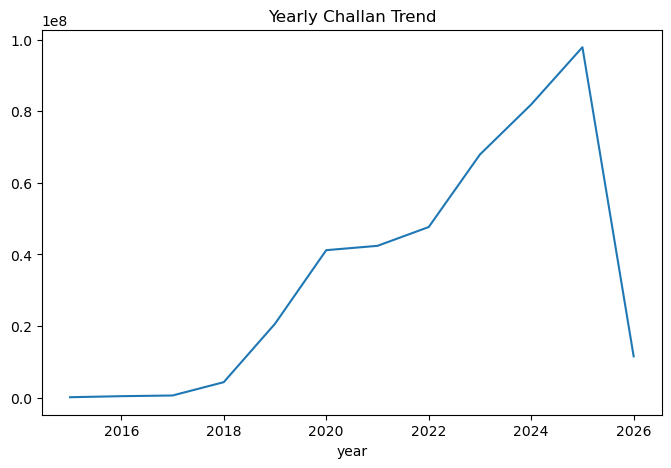

In [5]:
df["date"] = pd.to_datetime(df["date"])

df["year"] = df["date"].dt.year

yearly = df.groupby("year")["totalchallan"].sum()

yearly.plot(kind="line", figsize=(8,5), title="Yearly Challan Trend")

plt.show()

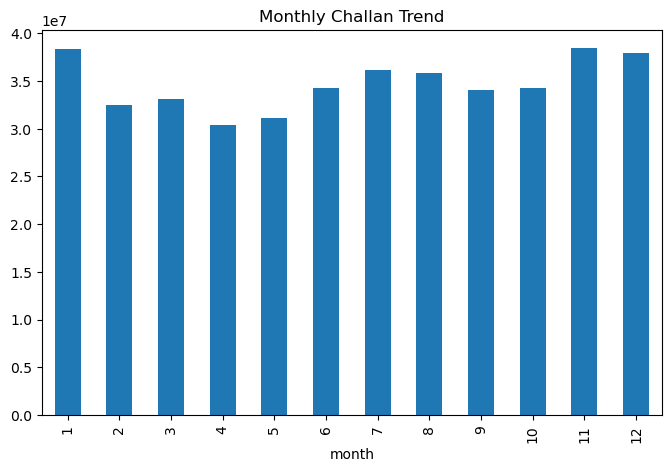

In [6]:
df["month"] = df["date"].dt.month

monthly = df.groupby("month")["totalchallan"].sum()

monthly.plot(kind="bar", figsize=(8,5), title="Monthly Challan Trend")

plt.show()

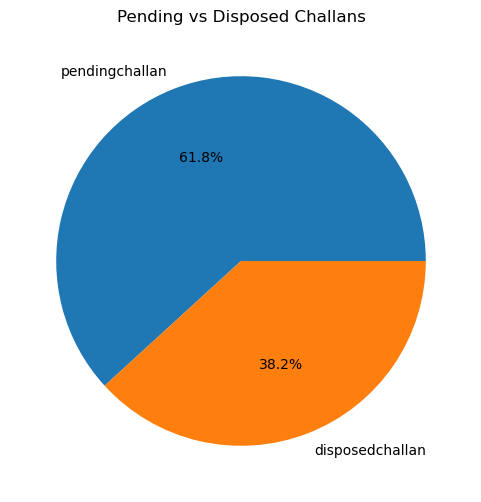

In [7]:
totals = df[["pendingchallan","disposedchallan"]].sum()

totals.plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))

plt.title("Pending vs Disposed Challans")

plt.show()